# Modèle de Machine Learning - Prédiction du Mariage Précoce

Contrairement à la statistique pure, le but du Machine Learning est de maximiser la **capacité prédictive** sur de nouvelles données. Nous allons entraîner un algorithme robuste pour le déploiement en production.

## 1. Importation, Architecture et Séparation des données
**Hold-out Method :** Nous divisons les données (80% entraînement, 20% test) pour évaluer le modèle sur des données qu'il n'a jamais vues. La stratification assure que la proportion de cas positifs/négatifs est la même dans les deux ensembles.

In [14]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

ROOT = Path.cwd()
PROJECT_ROOT = ROOT
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
TABLE_DIR = OUTPUTS_DIR / 'tables'
FIG_DIR = OUTPUTS_DIR / 'figures'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel('Dataset_Mariage_Precoce.xlsx', sheet_name='data')

categorical_cols = ['Region', 'Type_Residence', 'Niveau_Education', 'Religion', 'Indice_Richesse', 'Statut_Emploi', 'Ecoute_Radio', 'Regarde_TV']
X = pd.get_dummies(df[categorical_cols], drop_first=True)
X['Age_Actuel'] = df['Age_Actuel']
y = df['Mariage_Precoce']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train['Age_Actuel'] = scaler.fit_transform(X_train[['Age_Actuel']])
X_test['Age_Actuel'] = scaler.transform(X_test[['Age_Actuel']])


## 2. Optimisation des Hyperparamètres (GridSearchCV)
**GridSearchCV** teste méthodiquement de multiples combinaisons de paramètres (ex: la profondeur des arbres) avec une **validation croisée** (K-Fold). Le modèle ne valide pas sa performance sur un seul échantillon, mais sur plusieurs, garantissant une grande stabilité pour la production.

In [15]:
param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

gbc = GradientBoostingClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Meilleurs Hyperparamètres : {grid_search.best_params_}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Meilleurs Hyperparamètres : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}


## 3. Courbes d'Apprentissage (Learning Curves)
Ces courbes montrent l'évolution du score du modèle en fonction de la taille de l'échantillon d'entraînement. 
- Si les courbes d'entraînement et de validation se rejoignent à un haut niveau : le modèle est sain.
- Si elles sont éloignées : sur-apprentissage (overfitting).

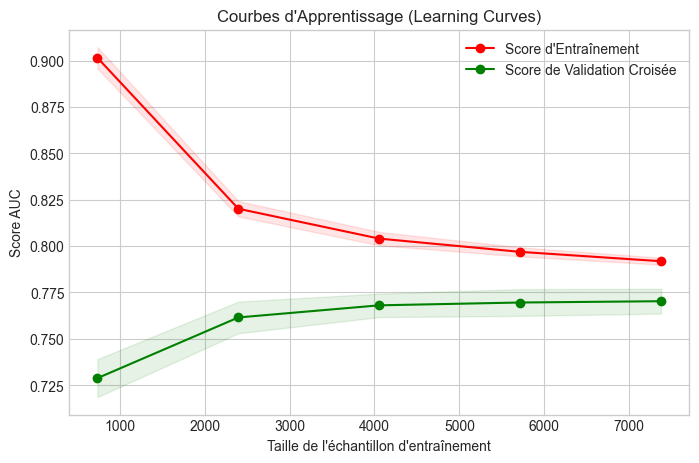

In [16]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Score d'Entraînement")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Score de Validation Croisée")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
plt.title("Courbes d'Apprentissage (Learning Curves)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score AUC")
plt.legend(loc="best")
plt.savefig(FIG_DIR / 'learning_curve.png', bbox_inches='tight')
plt.show()

## 4. Évaluation Globale de Généralisation
L'évaluation utilise des métriques clés :
- **Accuracy :** Le pourcentage total de prédictions correctes.
- **AUC-ROC :** La capacité du modèle à bien séparer les deux classes. 1.0 est parfait, 0.5 équivaut au hasard.
- **F1-Score :** Un compromis entre la Précision et le Rappel (très utile si les données sont déséquilibrées).

POURCENTAGE DE PERFORMANCE DE GÉNÉRALISATION TOTAL (ACCURACY) : 73.68%
SCORE AUC (Capacité de séparation) : 77.22%
SCORE F1 (Équilibre) : 54.53%

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.77      0.86      0.81      1553
           1       0.63      0.48      0.55       753

    accuracy                           0.74      2306
   macro avg       0.70      0.67      0.68      2306
weighted avg       0.73      0.74      0.73      2306



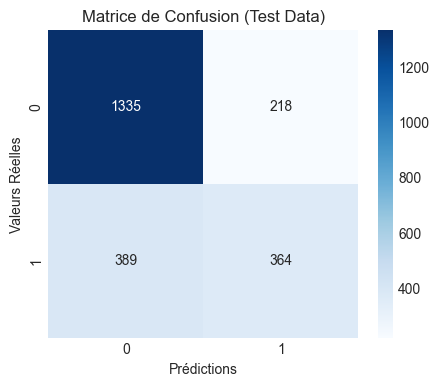

In [17]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print("="*60)
print(f"POURCENTAGE DE PERFORMANCE DE GÉNÉRALISATION TOTAL (ACCURACY) : {acc*100:.2f}%")
print(f"SCORE AUC (Capacité de séparation) : {auc_score*100:.2f}%")
print(f"SCORE F1 (Équilibre) : {f1*100:.2f}%")
print("="*60)

print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

# Matrice de confusion
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de Confusion (Test Data)")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
plt.savefig(FIG_DIR / 'confusion_matrix_prod.png', bbox_inches='tight')
plt.show()

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'F1-Score'],
    'Score (%)': [acc*100, auc_score*100, f1*100]
})
metrics_df.to_csv(TABLE_DIR / 'generalization_performance.csv', index=False)


### 4.1. Courbe ROC et Densité des Probabilités
Ces graphiques permettent de juger visuellement la capacité discriminante du modèle.

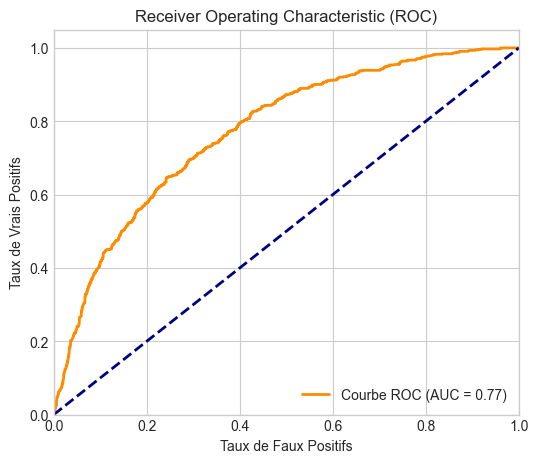

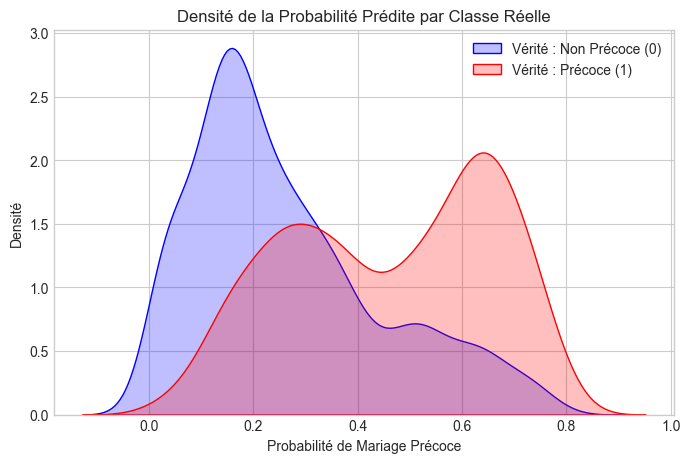

In [18]:
# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig(FIG_DIR / 'roc_curve.png', bbox_inches='tight')
plt.show()

# Densité des probabilités
plt.figure(figsize=(8, 5))
sns.kdeplot(y_proba[y_test == 0], fill=True, color="blue", label="Vérité : Non Précoce (0)")
sns.kdeplot(y_proba[y_test == 1], fill=True, color="red", label="Vérité : Précoce (1)")
plt.title("Densité de la Probabilité Prédite par Classe Réelle")
plt.xlabel("Probabilité de Mariage Précoce")
plt.ylabel("Densité")
plt.legend()
plt.savefig(FIG_DIR / 'prob_density.png', bbox_inches='tight')
plt.show()


## 5. Sauvegarde Sécurisée du Modèle Final pour Production

In [19]:
joblib.dump(best_model, OUTPUTS_DIR / 'best_model_mariage_precoce_prod.joblib')
joblib.dump(best_model, OUTPUTS_DIR / 'best_model_mariage_precoce_prod.pkl')
joblib.dump(scaler, OUTPUTS_DIR / 'scaler_age_prod.pkl')

print("Modèles sauvegardés avec succès dans le dossier 'outputs/'. Prêts pour l'application Streamlit.")


Modèles sauvegardés avec succès dans le dossier 'outputs/'. Prêts pour l'application Streamlit.
